# Convert Genes to Diseases

Transform for each patient a gene into a disease using orphacodes.
The knowledge dataset used is genes_associated_with_rare_diseases.xml. It is available at https://sciences.orphadata.com/genes/.


In [8]:
import pandas as pd
import xml.etree.ElementTree as ET

def parse_orphanet_xml(xml_file):
    # Charger et parser le fichier
    tree = ET.parse(xml_file)
    root = tree.getroot()
    
    results = []

    # On itère sur chaque balise <Disorder>
    for disorder in root.findall('.//Disorder'):
        orpha_code = disorder.find('OrphaCode').text
        # On spécifie lang='en' car il peut y avoir plusieurs balises Name
        disorder_name = disorder.find("./Name[@lang='en']").text
        
        # Un trouble peut avoir plusieurs gènes associés
        gene_associations = disorder.findall('.//DisorderGeneAssociation')
        
        for association in gene_associations:
            gene = association.find('Gene')
            if gene is not None:
                gene_symbol = gene.find('Symbol').text
                gene_code = gene.get("id")
                
                # Stockage des données
                results.append({
                    'OrphaCode': orpha_code,
                    'DiseaseName': disorder_name,
                    'GeneSymbol': gene_symbol,
                    'GeneId': gene_code
                })
                
    return results

# --- Utilisation ---
# Remplacez 'votre_fichier.xml' par le nom de votre fichier
data = parse_orphanet_xml('genes_associated_with_rare_diseases.xml')

# Conversion en DataFrame pour manipuler les données facilement
mappingGTD = pd.DataFrame(data) # Genes To Diseases

# Affichage des premières lignes
print(mappingGTD.head())

# Exemple pour sauvegarder en CSV
mappingGTD.to_csv('mapping_genes_maladies_orphanet_13_05_2026.csv', index=False)

  OrphaCode                                        DiseaseName GeneSymbol  \
0    166024  Multiple epiphyseal dysplasia-macrocephaly-fac...       KIF7   
1    166035  Brachydactyly-short stature-retinitis pigmento...      CWC27   
2        93                             Aspartylglucosaminuria        AGA   
3       585                      Multiple sulfatase deficiency      SUMF1   
4       118                                  Beta-mannosidosis      MANBA   

  GeneId  
0  20160  
1  26792  
2  15470  
3  15570  
4  16375  


## Checking
- Does the number of symbols match the size in the table? in file: 8374 gene _id
- Is it the same for diseases? In file: 4128 disorder_id
- How many genes are associated with multiple diseases? 

In [9]:
print("There are",mappingGTD["GeneSymbol"].nunique(), "unique gene symbols.")
print("There are",len(mappingGTD["GeneSymbol"]), "total gene symbols.")
print("There are", mappingGTD["OrphaCode"].nunique(), "unique disorder id.")

There are 4552 unique gene symbols.
There are 8374 total gene symbols.
There are 4128 unique disorder id.


### How many genes are associated with multiple diseases?

In [10]:
# 1. count how many diseases are linked to each gene.
gene_counts = mappingGTD.groupby("GeneSymbol")["OrphaCode"].nunique()

# 2. Filter genes associated with More than one disease.
multiple_diseases_genes = gene_counts[gene_counts > 1]

# 3. Display
print("Number of genes associated with multiple diseases:", {len(multiple_diseases_genes)})
print("Top 10 genes with the most associations:")
print(multiple_diseases_genes.sort_values(ascending=False).head(10))

Number of genes associated with multiple diseases: {1702}
Top 10 genes with the most associations:
GeneSymbol
HBB         29
LMNA        21
TP53        20
COL2A1      18
KIT         18
FGFR1       17
PIK3CA      15
HLA-DRB1    14
PTEN        14
TTN         13
Name: OrphaCode, dtype: int64


## Conversion for real data patient

Here we are using the patient data from exome sequencing in Rennes molecular genetics and medical genomics.

In [11]:
import ast
import re

In [12]:
patData = pd.read_csv("../../../data/raw_data/clinical_side/ehop_one_gene_export_with_keys.tsv", sep="\t")

rdPatData = patData[["ID_PAT_ETUDE", "IPP", "IPP_clef", "key_for_chaining", "gene_symbol",	"gene_hgnc_id"]].dropna()
rdPatData["gene_hgnc_id"] = rdPatData["gene_hgnc_id"].astype(str).str.replace(r'\.0$', '', regex=True)

# print(rdPatData.head())
print(rdPatData.shape)

(412, 6)


In [13]:
gene_counts = rdPatData.groupby('ID_PAT_ETUDE')['gene_symbol'].nunique()

# Stats
nb_multi_genes = (gene_counts > 1).sum()
nb_solo_gene = (gene_counts == 1).sum()
total_patients = rdPatData["ID_PAT_ETUDE"].nunique()

print(f"--- Statistiques Patients/Gènes ---")
print(f"Total de patients uniques : {total_patients}")
print(f"Patients avec 1 seul gène  : {nb_solo_gene} ({(nb_solo_gene/total_patients)*100:.1f}%)")
print(f"Patients avec plusieurs gènes : {nb_multi_genes} ({(nb_multi_genes/total_patients)*100:.1f}%)")

--- Statistiques Patients/Gènes ---
Total de patients uniques : 379
Patients avec 1 seul gène  : 379 (100.0%)
Patients avec plusieurs gènes : 0 (0.0%)


### Merging

In [14]:
#Same writing
rdPatData['gene_symbol'] = rdPatData['gene_symbol'].astype(str).str.strip().str.upper()
mappingGTD['GeneSymbol'] = mappingGTD['GeneSymbol'].astype(str).str.strip().str.upper()

# Merging
dfMerged = pd.merge(
    rdPatData,
    mappingGTD,
    left_on="gene_symbol",
    right_on="GeneSymbol",
    how="left"
)

# print(dfMerged.head())
print(dfMerged.shape)

# Identification of patients with multiple diseases possibility
counts = dfMerged.groupby("ID_PAT_ETUDE")["OrphaCode"].nunique()
patients_multi_diseases = counts[counts > 1].index

# Logs
log_data = dfMerged[dfMerged["ID_PAT_ETUDE"].isin(patients_multi_diseases)]
log_data = log_data.sort_values(by="ID_PAT_ETUDE")

# Ajouter une colonne qui indique combien de maladies ce patient a au total
dfMerged['NB_DISEASES_TOTAL'] = dfMerged.groupby('ID_PAT_ETUDE')['OrphaCode'].transform('nunique')

# Filtrer le log pour n'avoir que les cas complexes
log_data = dfMerged[dfMerged['NB_DISEASES_TOTAL'] > 1].sort_values(by=['NB_DISEASES_TOTAL', 'ID_PAT_ETUDE'], ascending=False)

# Saving
log_data.to_csv("patients_multi_diseases.csv", index=False)


(1120, 10)


In [33]:
# Stats summary
print(f"Number of total patients: {rdPatData["ID_PAT_ETUDE"].nunique()}")
print(f"Number of patients with multiple diseases found in log: {len(patients_multi_diseases)}")

# 1. Calcul of the number of disease per patient.
disease_counts = dfMerged.groupby('ID_PAT_ETUDE')['OrphaCode'].nunique()

# 2. Isolation multi-path patients
multi_dis_counts = disease_counts[disease_counts > 1]

# 3. Stats
nb_total_pat = rdPatData["ID_PAT_ETUDE"].nunique()
nb_multi_pat = len(multi_dis_counts)
moyenne_maladies = multi_dis_counts.mean()
mediane_maladies = multi_dis_counts.median()
max_maladies = multi_dis_counts.max()

print(f"--- Focus Patients with Multi-Diseases ---")
print(f"Number of patients with > 1 disease: {nb_multi_pat} ({(nb_multi_pat/nb_total_pat)*100:.2f}% du total)")
print(f"Mean of diseases for those patients: {moyenne_maladies:.2f}")
print(f"Median of diseases for those patients: {mediane_maladies}")
print(f"Maximum diseases for one patient: {max_maladies}")

# 4. Distribution (Frequences)
print("\n--- Distribution of the number of diseases ---")
distrib = multi_dis_counts.value_counts().sort_index()
for nb_maladies, nb_patients in distrib.items():
    pourcentage = (nb_patients / nb_multi_pat) * 100
    print(f"{nb_maladies} diseases: {nb_patients} patients ({pourcentage:.1f}%)")

Number of total patients: 379
Number of patients with multiple diseases found in log: 232
--- Focus Patients with Multi-Diseases ---
Number of patients with > 1 disease: 232 (61.21% du total)
Mean of diseases for those patients: 3.84
Median of diseases for those patients: 3.0
Maximum diseases for one patient: 18

--- Distribution of the number of diseases ---
2 diseases: 99 patients (42.7%)
3 diseases: 46 patients (19.8%)
4 diseases: 34 patients (14.7%)
5 diseases: 6 patients (2.6%)
6 diseases: 10 patients (4.3%)
7 diseases: 19 patients (8.2%)
8 diseases: 4 patients (1.7%)
9 diseases: 5 patients (2.2%)
10 diseases: 2 patients (0.9%)
11 diseases: 1 patients (0.4%)
12 diseases: 2 patients (0.9%)
14 diseases: 1 patients (0.4%)
15 diseases: 1 patients (0.4%)
17 diseases: 1 patients (0.4%)
18 diseases: 1 patients (0.4%)


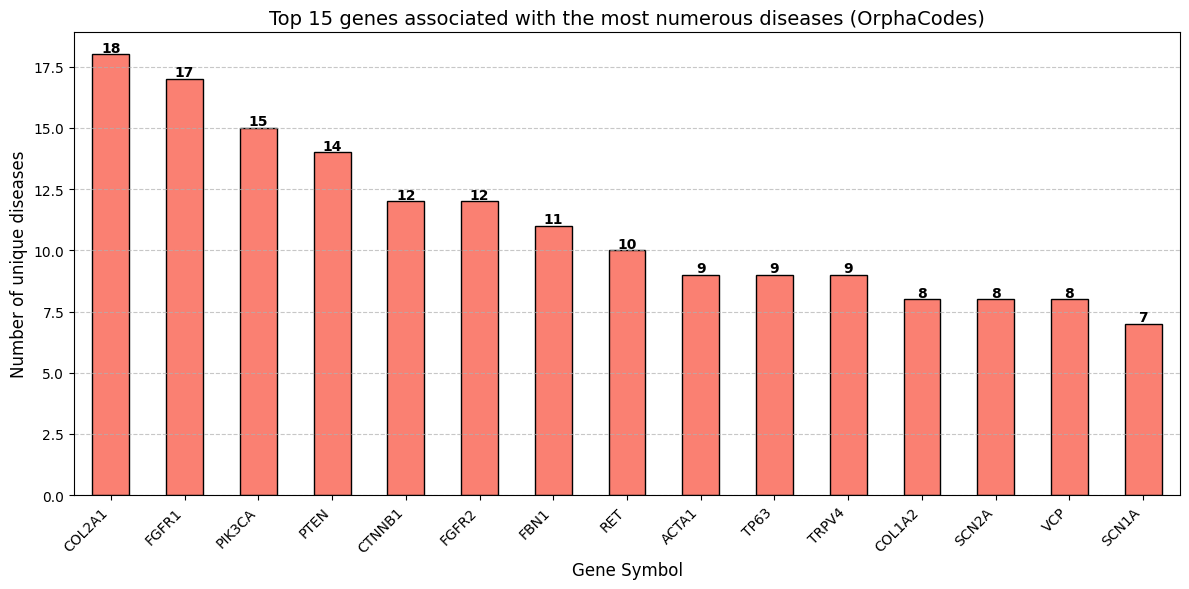

In [ ]:
import matplotlib.pyplot as plt

gene_impact = dfMerged.groupby('gene_symbol')['OrphaCode'].nunique().sort_values(ascending=False)

top_genes = gene_impact.head(15)

plt.figure(figsize=(12, 6))
top_genes.plot(kind='bar', color='salmon', edgecolor='black')

plt.title('Top 15 genes associated with the most numerous diseases (OrphaCodes)', fontsize=14)
plt.xlabel('Gene Symbol', fontsize=12)
plt.ylabel('Number of unique diseases', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, v in enumerate(top_genes):
    plt.text(i, v + 0.1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('top_genes_impact.png')

## App for choice

In [38]:
dfMerged["CR"] = "text à tester"

In [ ]:
from IPython.display import clear_output
import pandas as pd
import time

# 1. Préparation
if 'real_diseases_code' not in dfMerged.columns:
    dfMerged['real_diseases_code'] = None

# On cible les patients restants
pats_to_review = dfMerged[
    (dfMerged['NB_DISEASES_TOTAL'] > 1) & 
    (dfMerged['real_diseases_code'].isna())
]['ID_PAT_ETUDE'].unique()

print(f"--- Session d'annotation : {len(pats_to_review)} patients ---")

for i, pat_id in enumerate(pats_to_review):
    pat_data = dfMerged[dfMerged['ID_PAT_ETUDE'] == pat_id]
    
    # ÉTAPE A : Nettoyage et affichage massif
    clear_output(wait=True)
    
    print("="*60)
    print(f" PATIENT {i+1}/{len(pats_to_review)} | ID: {pat_id}")
    print("="*60)
    print(f"\n[COMPTE-RENDU MÉDICAL]\n")
    print(pat_data['CR'].iloc[0])
    print("\n" + "-"*60)
    print(f"GÈNES IDENTIFIÉS : {list(pat_data['gene_symbol'].unique())}")
    print("\nOPTIONS DISPONIBLES :")
    
    options = {}
    choices = pat_data[['OrphaCode', 'DiseaseName']].drop_duplicates()
    for idx, (_, row) in enumerate(choices.iterrows(), 1):
        options[str(idx)] = row['OrphaCode']
        print(f"  [{idx}] -> {row['DiseaseName']} (Code: {row['OrphaCode']})")
    
    print("\n[S] : Passer | [Q] : Quitter")
    print("-"*60)

    # ÉTAPE B : Le Verrou (Synchronisation de l'affichage)
    # Ce premier input force l'affichage de tout ce qui précède
    input("\n>>> APPUYEZ SUR ENTRÉE POUR SAISIR VOTRE CHOIX <<<")

    # ÉTAPE C : La Saisie Réelle
    user_input = input("VOTRE DÉCISION (ex: 1 ou 1,2) : ").strip().lower()

    # ÉTAPE D : Traitement
    if user_input == 'q':
        print("\nArrêt et sauvegarde...")
        break
    elif user_input == 's':
        continue
    elif user_input == '':
        input("Saisie vide. Appuyez sur Entrée pour recharger ce patient.")
        # On utilise un "continue" sans enregistrer pour boucler sur le même patient
        # (Techniquement il faut gérer l'index, mais ici on va juste relancer le script)
        continue
    else:
        try:
            # On nettoie la saisie (espaces, virgules)
            clean_input = user_input.replace(',', ' ').split()
            selected_codes = [options[idx] for idx in clean_input if idx in options]

            if not selected_codes:
                input("Aucun chiffre valide détecté. Entrée pour recommencer.")
                continue

            # Enregistrement
            dfMerged.loc[dfMerged['ID_PAT_ETUDE'] == pat_id, 'real_diseases_code'] = str(selected_codes)
            
            # Sauvegarde de secours
            dfMerged.to_csv("checkpoint_final.csv", index=False)
            
        except Exception as e:
            input(f"Erreur imprévue : {e}. Entrée pour continuer.")
            continue

print("\nSession terminée. Vos données sont dans 'checkpoint_final.csv'.")